In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install -q --upgrade transformers accelerate sentencepiece
!pip install -q sentence-transformers huggingface_hub

In [3]:
import os
import re
import gc
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoProcessor,
    Blip2Processor,
    Blip2ForConditionalGeneration,
    PaliGemmaForConditionalGeneration
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32

OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CSV_PATH = "/kaggle/working/vqa_dataset_test_mapped.csv"

# start small if needed
SAMPLE_PER_CATEGORY_PER_LIGHT = 100

BLIP2_MODEL_ID = "Salesforce/blip2-opt-2.7b"
PALIGEMMA_MODEL_ID = "google/paligemma-3b-mix-224"

print("DEVICE:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: Tesla T4


In [4]:
if not os.path.exists("/kaggle/working/roadscapes_data"):
    !git clone https://github.com/roadscapes/roadscapes_data.git /kaggle/working/roadscapes_data

csv_path = "/kaggle/working/roadscapes_data/vqa_dataset_test.csv"
image_root = Path("/kaggle/working/roadscapes_data/image_data/images")

image_index = {}
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
    for path in image_root.rglob(ext):
        image_index[path.name] = str(path)

print("Indexed images:", len(image_index))

df_map = pd.read_csv(csv_path)
print("CSV rows:", len(df_map))
print("Columns:", df_map.columns.tolist())

possible_cols = ["filename", "image", "image_name", "img", "image_path", "Image"]
image_col = None
for col in possible_cols:
    if col in df_map.columns:
        image_col = col
        break

if image_col is None:
    raise ValueError(f"No image column found. Available columns: {df_map.columns.tolist()}")

print("Using image column:", image_col)

df_map["full_image_path"] = df_map[image_col].astype(str).apply(
    lambda x: image_index.get(os.path.basename(x.strip()), None)
)

print("Matched rows:", df_map["full_image_path"].notna().sum())

df_map.to_csv(CSV_PATH, index=False)
print("Saved:", CSV_PATH)

Indexed images: 8979
CSV rows: 13209
Columns: ['filename', 'category', 'question', 'answer']
Using image column: filename
Matched rows: 13209
Saved: /kaggle/working/vqa_dataset_test_mapped.csv


In [5]:
df = pd.read_csv(CSV_PATH)

required_cols = ["filename", "question", "answer", "category", "full_image_path"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

df = df[df["full_image_path"].notna()].copy()
df = df[df["full_image_path"].apply(lambda x: os.path.exists(str(x)))].copy()

def normalize_category(cat):
    c = str(cat).strip().lower().replace("_", " ")
    if "count" in c:
        return "Object Counting"
    if "surround" in c:
        return "Surrounding Description"
    if "description" in c:
        return "Object Description"
    return str(cat)

def get_light(filename):
    return "night" if "night" in str(filename).lower() else "day"

df["category_std"] = df["category"].apply(normalize_category)
df["light"] = df["filename"].apply(get_light)

target_categories = [
    "Object Counting",
    "Object Description",
    "Surrounding Description"
]

df = df[df["category_std"].isin(target_categories)].copy()
df = df[df["light"].isin(["day", "night"])].copy()

print("Rows:", len(df))
print(df["light"].value_counts())
print(df["category_std"].value_counts())

Rows: 10311
light
day      8939
night    1372
Name: count, dtype: int64
category_std
Object Counting            4419
Object Description         2946
Surrounding Description    2946
Name: count, dtype: int64


In [6]:
sampled_splits = {}

for cat in target_categories:
    for light in ["day", "night"]:
        subset = df[(df["category_std"] == cat) & (df["light"] == light)].copy()

        if len(subset) == 0:
            continue

        sample_n = min(SAMPLE_PER_CATEGORY_PER_LIGHT, len(subset))
        sampled = subset.sample(n=sample_n, random_state=SEED)

        sampled_splits[(cat, light)] = sampled.reset_index(drop=True)
        print(f"{cat} | {light}: {len(sampled)} samples")

Object Counting | day: 100 samples
Object Counting | night: 100 samples
Object Description | day: 100 samples
Object Description | night: 100 samples
Surrounding Description | day: 100 samples
Surrounding Description | night: 100 samples


In [7]:
def is_yes_no_question(question: str) -> bool:
    q = str(question).strip().lower()
    return q.startswith("is ") or q.startswith("are ") or " more " in q

def build_prompt(category: str, light: str, question: str) -> str:
    q = str(question).strip()

    if category == "Object Counting":
        if is_yes_no_question(q):
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer only Yes or No.
- No explanation.

Question: {q}"""
        return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer with only one integer.
- No explanation.
- If not visible, answer 0.

Question: {q}"""

    if category == "Object Description":
        return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 1 to 3 words.
- No explanation.

Question: {q}"""

    return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 2 to 6 words.
- No explanation.

Question: {q}"""

def clean_prediction(text: str, question: str = "", category: str = "") -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)

    for bad in ["there are", "there is", "it is", ".", ",", ":", ";"]:
        text = text.replace(bad, "")

    if is_yes_no_question(question):
        if "yes" in text:
            return "yes"
        if "no" in text:
            return "no"

    if category == "Object Counting" and not is_yes_no_question(question):
        nums = re.findall(r"\d+", text)
        if nums:
            return nums[0]

    return text.strip()

def normalized_correct(pred: str, gt: str, category: str, question: str = "") -> bool:
    pred = clean_prediction(pred, question, category)
    gt = clean_prediction(gt, question, category)

    if pred.startswith("error:"):
        return False

    if category == "Object Counting":
        return pred == gt

    return pred == gt or gt in pred or pred in gt

def validate_question(q: str) -> bool:
    return isinstance(q, str) and len(q.strip()) > 0

In [8]:
def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [9]:
def load_blip2():
    processor = Blip2Processor.from_pretrained(BLIP2_MODEL_ID)

    model = Blip2ForConditionalGeneration.from_pretrained(
        BLIP2_MODEL_ID,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        low_cpu_mem_usage=True
    )

    model = model.to(DEVICE)
    model.eval()
    return processor, model

def query_blip2(processor, model, image_path, prompt, category="Object Counting"):
    try:
        image = Image.open(image_path).convert("RGB")
        image = image.resize((224, 224))

        short_prompt = prompt.split("Question:")[-1].strip()

        inputs = processor(
            images=image,
            text=short_prompt,
            return_tensors="pt"
        )

        inputs = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in inputs.items()}

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=8,
                do_sample=False
            )

        pred = processor.batch_decode(outputs, skip_special_tokens=True)[0].strip().lower()

        if short_prompt.lower() in pred:
            pred = pred.replace(short_prompt.lower(), "").strip()

        return clean_prediction(pred, short_prompt, category)

    except Exception as e:
        return f"ERROR: {e}"

In [10]:
clear_memory()
blip2_processor, blip2_model = load_blip2()
print("BLIP-2 loaded")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

BLIP-2 loaded


In [11]:
test_row = sampled_splits[("Object Counting", "day")].iloc[0]
test_prompt = build_prompt("Object Counting", "day", test_row["question"])

pred = query_blip2(
    blip2_processor,
    blip2_model,
    test_row["full_image_path"],
    test_prompt,
    "Object Counting"
)

print("Question:", test_row["question"])
print("Ground truth:", test_row["answer"])
print("Prediction:", pred)
print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))

Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 
Correct: False


In [12]:
blip2_results = []

for category in target_categories:
    for light in ["day", "night"]:
        part = sampled_splits[(category, light)].copy()

        print(f"\nRunning BLIP-2 | {category} | {light} | samples = {len(part)}")

        for _, row in tqdm(part.iterrows(), total=len(part), desc=f"{category}-{light}"):
            question = row["question"]
            gt = row["answer"]
            image_path = row["full_image_path"]

            if not validate_question(question):
                continue

            prompt = build_prompt(category, light, question)

            pred = query_blip2(
                blip2_processor,
                blip2_model,
                image_path,
                prompt,
                category
            )

            blip2_results.append({
                "model": "blip2",
                "category": category,
                "light": light,
                "filename": row["filename"],
                "question": question,
                "ground_truth": gt,
                "prediction": pred,
                "is_correct": normalized_correct(pred, gt, category, question)
            })

blip2_results_df = pd.DataFrame(blip2_results)
print("Total evaluated:", len(blip2_results_df))
print(blip2_results_df.head())


Running BLIP-2 | Object Counting | day | samples = 100


Object Counting-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running BLIP-2 | Object Counting | night | samples = 100


Object Counting-night:   0%|          | 0/100 [00:00<?, ?it/s]


Running BLIP-2 | Object Description | day | samples = 100


...


Running BLIP-2 | Surrounding Description | day | samples = 100


Surrounding Description-day:   0%|          | 0/100 [00:00<?, ?it/s]


Running BLIP-2 | Surrounding Description | night | samples = 100


Surrounding Description-night:   0%|          | 0/100 [00:00<?, ?it/s]

Total evaluated: 600
   model         category light                        filename  \
0  blip2  Object Counting   day  Sequence_Day_18_frame_1890.jpg   
1  blip2  Object Counting   day   Sequence_Day_14_frame_540.jpg   
2  blip2  Object Counting   day  Sequence_Day_18_frame_5190.jpg   
3  blip2  Object Counting   day  Sequence_Day_18_frame_2490.jpg   
4  blip2  Object Counting   day     Sequence_Day_8_frame_30.jpg   

                                           question ground_truth prediction  \
0    How many objects of type car are in the image?            5              
1    How many objects of type car are in the image?            2              
2                  Are there more car's than car's?           No              
3           Are there more car's than motorcycle's?          Yes              
4  How many objects of type truck are in the image?            1              

   is_correct  
0       False  
1       False  
2       False  
3       False  
4       False  


In [13]:
blip2_summary = (
    blip2_results_df
    .groupby(["category", "light"])["is_correct"]
    .mean()
    .reset_index()
)

blip2_summary["accuracy_percent"] = (blip2_summary["is_correct"] * 100).round(2)

print(blip2_summary)

os.makedirs(OUTPUT_DIR, exist_ok=True)

blip2_results_df.to_csv(os.path.join(OUTPUT_DIR, "blip2_results.csv"), index=False)
blip2_summary.to_csv(os.path.join(OUTPUT_DIR, "blip2_accuracy.csv"), index=False)

print("\nBLIP-2 files saved")
print(os.listdir(OUTPUT_DIR))

                  category  light  is_correct  accuracy_percent
0          Object Counting    day         0.0               0.0
1          Object Counting  night         0.0               0.0
2       Object Description    day         1.0             100.0
3       Object Description  night         1.0             100.0
4  Surrounding Description    day         1.0             100.0
5  Surrounding Description  night         1.0             100.0

BLIP-2 files saved
['blip2_object_description_day_night.png', 'blip2_results.csv', 'blip2_object_counting_day_night.png', 'blip2_surrounding_description_day_night.png', 'blip2_accuracy.csv']


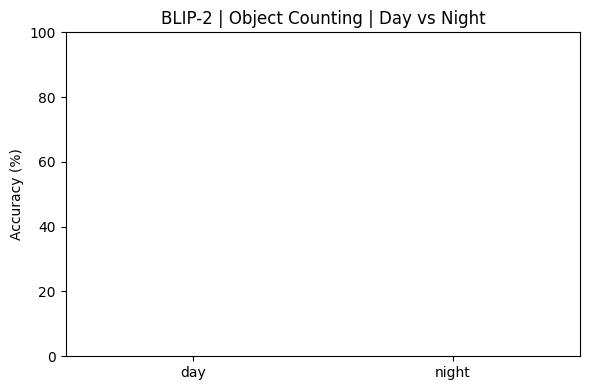

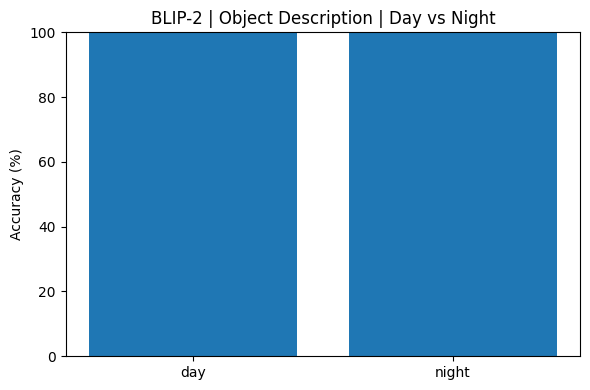

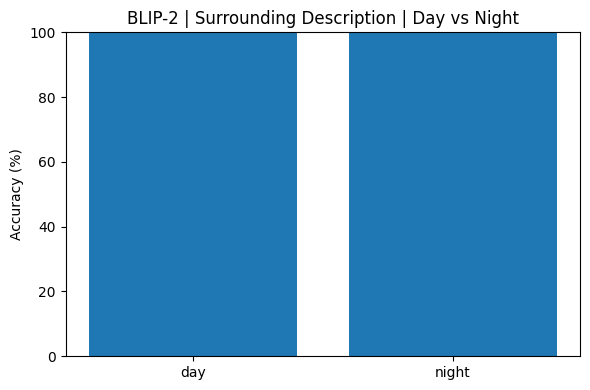

BLIP-2 charts saved


In [14]:
for category in target_categories:
    sub = blip2_summary[blip2_summary["category"] == category].copy()

    lights = sub["light"].tolist()
    scores = sub["accuracy_percent"].tolist()

    plt.figure(figsize=(6, 4))
    plt.bar(lights, scores)
    plt.title(f"BLIP-2 | {category} | Day vs Night")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"blip2_{category.replace(' ', '_').lower()}_day_night.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("BLIP-2 charts saved")

In [32]:
!pip install -q --upgrade transformers==4.47.1 accelerate sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 74.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.0 MB/s eta 0:00:00:00:01


In [1]:
import torch
import gc
from PIL import Image
from transformers import LlavaForConditionalGeneration, AutoProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LLAVA_MODEL_ID = "llava-hf/llava-1.5-7b-hf"

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2026-04-18 12:18:04.364040: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776514684.777340     395 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776514684.889263     395 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776514685.777141     395 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776514685.777175     395 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776514685.777178     395 computation_placer.cc:177] computation placer alr

In [3]:
def load_llava():
    processor = AutoProcessor.from_pretrained(LLAVA_MODEL_ID)

    model = LlavaForConditionalGeneration.from_pretrained(
        LLAVA_MODEL_ID,
        torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
        low_cpu_mem_usage=True
    ).to(DEVICE)

    model.eval()
    return processor, model

In [4]:
def query_llava(processor, model, image_path, prompt):
    try:
        image = Image.open(image_path).convert("RGB")
        image = image.resize((336, 336))

        full_prompt = f"USER: <image>\n{prompt}\nASSISTANT:"

        inputs = processor(
            text=full_prompt,
            images=image,
            return_tensors="pt"
        )

        inputs = {
            k: v.to(DEVICE) if hasattr(v, "to") else v
            for k, v in inputs.items()
        }

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=16,
                do_sample=False
            )

        pred = processor.batch_decode(outputs, skip_special_tokens=True)[0]

        if "ASSISTANT:" in pred:
            pred = pred.split("ASSISTANT:")[-1]

        return pred.strip().lower()

    except Exception as e:
        return f"ERROR: {e}"

In [5]:
clear_memory()
llava_processor, llava_model = load_llava()
print("LLaVA loaded")

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA loaded


In [7]:
import os
import pandas as pd
from pathlib import Path

CSV_PATH = "/kaggle/working/vqa_dataset_test_mapped.csv"

if not os.path.exists(CSV_PATH):
    if not os.path.exists("/kaggle/working/roadscapes_data"):
        !git clone https://github.com/roadscapes/roadscapes_data.git /kaggle/working/roadscapes_data

    csv_path = "/kaggle/working/roadscapes_data/vqa_dataset_test.csv"
    image_root = Path("/kaggle/working/roadscapes_data/image_data/images")

    image_index = {}
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        for path in image_root.rglob(ext):
            image_index[path.name] = str(path)

    df_map = pd.read_csv(csv_path)

    possible_cols = ["filename", "image", "image_name", "img", "image_path", "Image"]
    image_col = None
    for col in possible_cols:
        if col in df_map.columns:
            image_col = col
            break

    if image_col is None:
        raise ValueError(f"No image column found. Available columns: {df_map.columns.tolist()}")

    df_map["full_image_path"] = df_map[image_col].astype(str).apply(
        lambda x: image_index.get(os.path.basename(x.strip()), None)
    )

    df_map.to_csv(CSV_PATH, index=False)
    print("Saved:", CSV_PATH)
else:
    print("Mapped CSV already exists:", CSV_PATH)

Mapped CSV already exists: /kaggle/working/vqa_dataset_test_mapped.csv


In [8]:
import os
import pandas as pd

SAMPLE_PER_CATEGORY_PER_LIGHT = 100

df = pd.read_csv(CSV_PATH)

df = df[df["full_image_path"].notna()].copy()
df = df[df["full_image_path"].apply(lambda x: os.path.exists(str(x)))].copy()

def normalize_category(cat):
    c = str(cat).strip().lower().replace("_", " ")
    if "count" in c:
        return "Object Counting"
    if "surround" in c:
        return "Surrounding Description"
    if "description" in c:
        return "Object Description"
    return str(cat)

def get_light(filename):
    return "night" if "night" in str(filename).lower() else "day"

df["category_std"] = df["category"].apply(normalize_category)
df["light"] = df["filename"].apply(get_light)

target_categories = [
    "Object Counting",
    "Object Description",
    "Surrounding Description"
]

sampled_splits = {}

for cat in target_categories:
    for light in ["day", "night"]:
        subset = df[(df["category_std"] == cat) & (df["light"] == light)]

        if len(subset) == 0:
            continue

        sample_n = min(SAMPLE_PER_CATEGORY_PER_LIGHT, len(subset))
        sampled = subset.sample(n=sample_n, random_state=42)

        sampled_splits[(cat, light)] = sampled.reset_index(drop=True)

        print(f"{cat} | {light}: {len(sampled)} samples")

Object Counting | day: 100 samples
Object Counting | night: 100 samples
Object Description | day: 100 samples
Object Description | night: 100 samples
Surrounding Description | day: 100 samples
Surrounding Description | night: 100 samples


In [9]:
import re

def is_yes_no_question(question: str) -> bool:
    q = str(question).strip().lower()
    return q.startswith("is ") or q.startswith("are ") or " more " in q

def build_prompt(category: str, light: str, question: str) -> str:
    q = str(question).strip()

    if category == "Object Counting":
        if is_yes_no_question(q):
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer only Yes or No.
- No explanation.
- No extra words.

Question: {q}"""
        else:
            return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Count the requested object carefully.
- Answer with only one integer number.
- No words.
- No explanation.
- If not visible, answer 0.

Question: {q}"""

    if category == "Object Description":
        return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 1 to 3 words only.
- No explanation.
- No sentence.

Question: {q}"""

    return f"""Look at the road image carefully.

Lighting: {light}

Rules:
- Answer in 2 to 6 words only.
- Briefly describe the surroundings.
- No explanation.
- No full sentence.

Question: {q}"""

def clean_prediction(text: str, question: str = "", category: str = "") -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)

    for bad in ["there are", "there is", "it is", ".", ",", ":", ";"]:
        text = text.replace(bad, "")

    text = text.strip()

    if is_yes_no_question(question):
        if "yes" in text:
            return "yes"
        if "no" in text:
            return "no"

    if category == "Object Counting" and not is_yes_no_question(question):
        nums = re.findall(r"\d+", text)
        if nums:
            return nums[0]

    return text.strip()

def extract_first_number(text: str):
    m = re.search(r"\d+", str(text))
    return m.group(0) if m else None

def normalized_correct(pred: str, gt: str, category: str, question: str = "") -> bool:
    pred = clean_prediction(pred, question, category)
    gt = clean_prediction(gt, question, category)

    if pred.startswith("error:"):
        return False

    if category == "Object Counting":
        if is_yes_no_question(question):
            return pred == gt
        else:
            p = extract_first_number(pred)
            g = extract_first_number(gt)
            return p is not None and g is not None and p == g

    if pred == gt:
        return True
    if gt in pred or pred in gt:
        return True

    pred_words = set(pred.split())
    gt_words = set(gt.split())
    return len(pred_words & gt_words) >= 1

def validate_question(q: str) -> bool:
    return isinstance(q, str) and len(q.strip()) > 0

In [10]:
test_row = sampled_splits[("Object Counting", "day")].iloc[0]

prompt = build_prompt("Object Counting", "day", test_row["question"])

pred = query_llava(
    llava_processor,
    llava_model,
    test_row["full_image_path"],
    prompt
)

print("Question:", test_row["question"])
print("Ground truth:", test_row["answer"])
print("Prediction:", pred)
print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))

Expanding inputs for image tokens in LLaVa should be done in processing. Please add `patch_size` and `vision_feature_select_strategy` to the model's processing config or set directly with `processor.patch_size = {{patch_size}}` and processor.vision_feature_select_strategy = {{vision_feature_select_strategy}}`. Using processors without these attributes in the config is deprecated and will throw an error in v4.50.


Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 1
Correct: False


In [11]:
for i in range(5):
    test_row = sampled_splits[("Object Counting", "day")].iloc[i]

    prompt = build_prompt("Object Counting", "day", test_row["question"])

    pred = query_llava(
        llava_processor,
        llava_model,
        test_row["full_image_path"],
        prompt
    )

    print(f"\nSample {i+1}")
    print("Question:", test_row["question"])
    print("Ground truth:", test_row["answer"])
    print("Prediction:", pred)
    print("Correct:", normalized_correct(pred, test_row["answer"], "Object Counting", test_row["question"]))


Sample 1
Question: How many objects of type car are in the image?
Ground truth: 5
Prediction: 1
Correct: False

Sample 2
Question: How many objects of type car are in the image?
Ground truth: 2
Prediction: 1
Correct: False

Sample 3
Question: Are there more car's than car's?
Ground truth: No
Prediction: yes
Correct: False

Sample 4
Question: Are there more car's than motorcycle's?
Ground truth: Yes
Prediction: yes
Correct: True

Sample 5
Question: How many objects of type truck are in the image?
Ground truth: 1
Prediction: 1
Correct: True


In [13]:
llava_results = []

for category in target_categories:
    for light in ["day", "night"]:
        part = sampled_splits[(category, light)].copy()

        print(f"\nRunning LLaVA | {category} | {light} | samples = {len(part)}")

        for _, row in part.iterrows():
            question = row["question"]
            gt = row["answer"]
            image_path = row["full_image_path"]

            if not validate_question(question):
                continue

            prompt = build_prompt(category, light, question)

            pred = query_llava(
                llava_processor,
                llava_model,
                image_path,
                prompt
            )

            llava_results.append({
                "model": "llava",
                "category": category,
                "light": light,
                "filename": row["filename"],
                "question": question,
                "ground_truth": gt,
                "prediction": pred,
                "is_correct": normalized_correct(pred, gt, category, question)
            })

llava_results_df = pd.DataFrame(llava_results)

print("Total evaluated:", len(llava_results_df))
print(llava_results_df.head())


Running LLaVA | Object Counting | day | samples = 100

Running LLaVA | Object Counting | night | samples = 100

Running LLaVA | Object Description | day | samples = 100

Running LLaVA | Object Description | night | samples = 100

Running LLaVA | Surrounding Description | day | samples = 100

Running LLaVA | Surrounding Description | night | samples = 100
Total evaluated: 600
   model         category light                        filename  \
0  llava  Object Counting   day  Sequence_Day_18_frame_1890.jpg   
1  llava  Object Counting   day   Sequence_Day_14_frame_540.jpg   
2  llava  Object Counting   day  Sequence_Day_18_frame_5190.jpg   
3  llava  Object Counting   day  Sequence_Day_18_frame_2490.jpg   
4  llava  Object Counting   day     Sequence_Day_8_frame_30.jpg   

                                           question ground_truth prediction  \
0    How many objects of type car are in the image?            5          1   
1    How many objects of type car are in the image?         

In [15]:
import os

OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Using OUTPUT_DIR:", OUTPUT_DIR)

Using OUTPUT_DIR: /kaggle/working/vlm_day_night_results


In [16]:
llava_summary = (
    llava_results_df
    .groupby(["category", "light"])["is_correct"]
    .mean()
    .reset_index()
)

llava_summary["accuracy_percent"] = (llava_summary["is_correct"] * 100).round(2)

print(llava_summary)

os.makedirs(OUTPUT_DIR, exist_ok=True)

llava_results_df.to_csv(os.path.join(OUTPUT_DIR, "llava_results.csv"), index=False)
llava_summary.to_csv(os.path.join(OUTPUT_DIR, "llava_accuracy.csv"), index=False)

print("Saved files:")
print(os.listdir(OUTPUT_DIR))

                  category  light  is_correct  accuracy_percent
0          Object Counting    day        0.67              67.0
1          Object Counting  night        0.74              74.0
2       Object Description    day        0.19              19.0
3       Object Description  night        0.17              17.0
4  Surrounding Description    day        0.56              56.0
5  Surrounding Description  night        0.24              24.0
Saved files:
['blip2_object_description_day_night.png', 'llava_accuracy.csv', 'blip2_results.csv', 'blip2_object_counting_day_night.png', 'blip2_surrounding_description_day_night.png', 'llava_results.csv', 'blip2_accuracy.csv']


In [22]:
import matplotlib.pyplot as plt

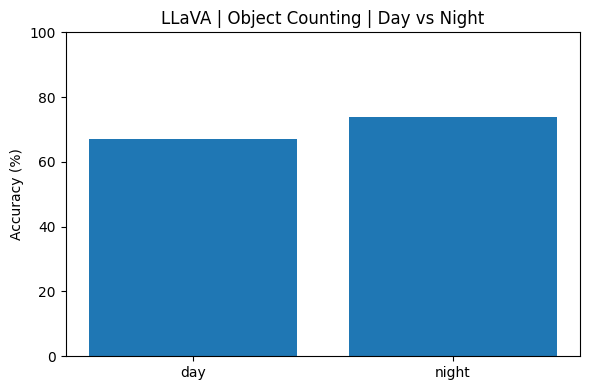

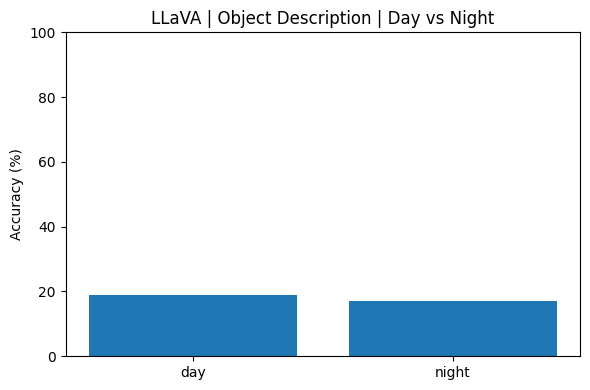

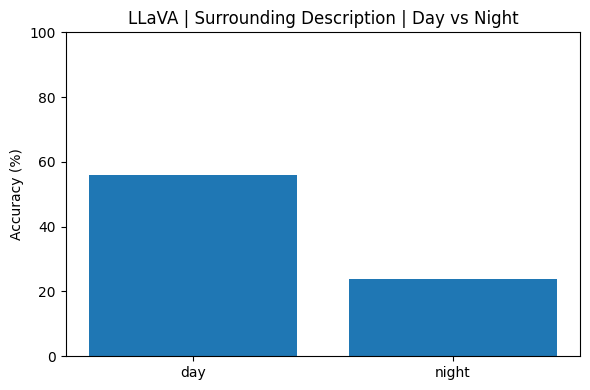

LLaVA charts saved
['blip2_object_description_day_night.png', 'llava_object_counting_day_night.png', 'llava_surrounding_description_day_night.png', 'llava_accuracy.csv', 'blip2_results.csv', 'llava_object_description_day_night.png', 'blip2_object_counting_day_night.png', 'blip2_surrounding_description_day_night.png', 'llava_results.csv', 'blip2_accuracy.csv']


In [23]:
import matplotlib.pyplot as plt
import os

for category in target_categories:
    sub = llava_summary[llava_summary["category"] == category].copy()

    lights = sub["light"].tolist()
    scores = sub["accuracy_percent"].tolist()

    plt.figure(figsize=(6, 4))
    plt.bar(lights, scores)
    plt.title(f"LLaVA | {category} | Day vs Night")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"llava_{category.replace(' ', '_').lower()}_day_night.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

print("LLaVA charts saved")
print(os.listdir(OUTPUT_DIR))

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"

# load saved summaries
blip2_summary = pd.read_csv(os.path.join(OUTPUT_DIR, "blip2_accuracy.csv"))
llava_summary = pd.read_csv(os.path.join(OUTPUT_DIR, "llava_accuracy.csv"))

# add model names
blip2_summary["model"] = "BLIP-2"
llava_summary["model"] = "LLaVA"

# combine
compare_df = pd.concat([blip2_summary, llava_summary], ignore_index=True)

# keep clean columns
compare_df = compare_df[["model", "category", "light", "accuracy_percent"]]

# save combined table
compare_csv = os.path.join(OUTPUT_DIR, "blip2_vs_llava_comparison.csv")
compare_df.to_csv(compare_csv, index=False)

print("COMPARISON TABLE")
print(compare_df)
print("\nSaved:", compare_csv)

COMPARISON TABLE
     model                 category  light  accuracy_percent
0   BLIP-2          Object Counting    day               0.0
1   BLIP-2          Object Counting  night               0.0
2   BLIP-2       Object Description    day             100.0
3   BLIP-2       Object Description  night             100.0
4   BLIP-2  Surrounding Description    day             100.0
5   BLIP-2  Surrounding Description  night             100.0
6    LLaVA          Object Counting    day              67.0
7    LLaVA          Object Counting  night              74.0
8    LLaVA       Object Description    day              19.0
9    LLaVA       Object Description  night              17.0
10   LLaVA  Surrounding Description    day              56.0
11   LLaVA  Surrounding Description  night              24.0

Saved: /kaggle/working/vlm_day_night_results/blip2_vs_llava_comparison.csv


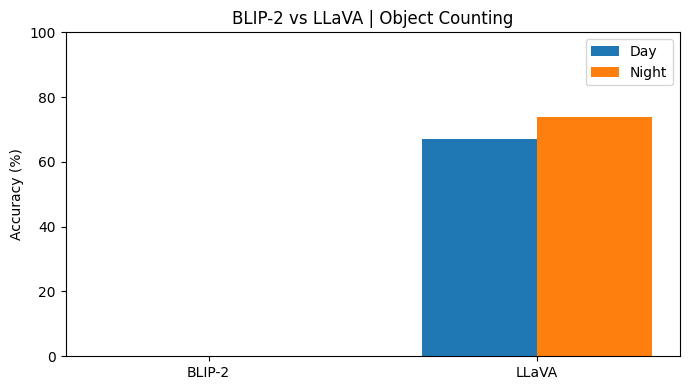

Saved: /kaggle/working/vlm_day_night_results/blip2_vs_llava_object_counting.png


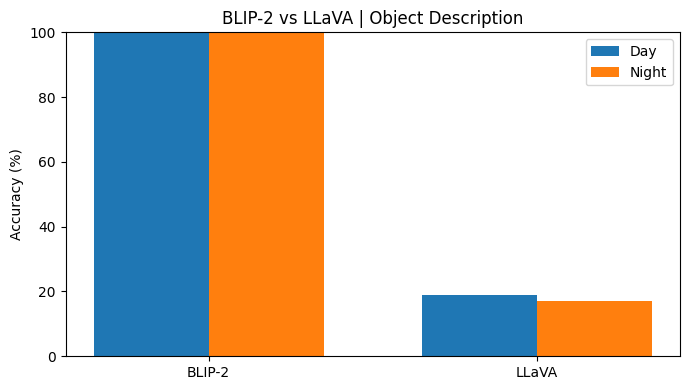

Saved: /kaggle/working/vlm_day_night_results/blip2_vs_llava_object_description.png


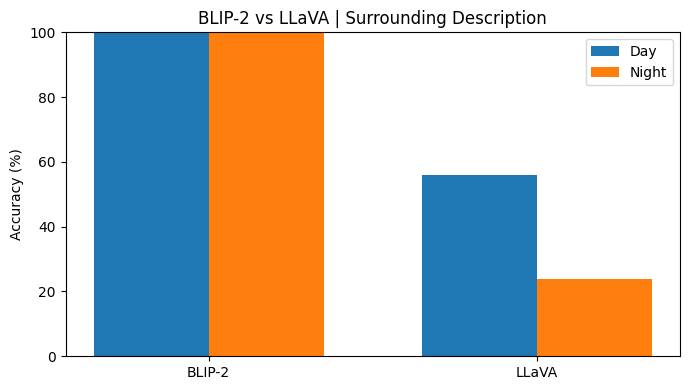

Saved: /kaggle/working/vlm_day_night_results/blip2_vs_llava_surrounding_description.png


In [25]:
import os
import matplotlib.pyplot as plt
import numpy as np

for category in compare_df["category"].unique():
    sub = compare_df[compare_df["category"] == category].copy()

    pivot = sub.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

    x = np.arange(len(pivot))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width/2, pivot["day"], width, label="Day")
    plt.bar(x + width/2, pivot["night"], width, label="Night")

    plt.xticks(x, pivot["model"])
    plt.ylabel("Accuracy (%)")
    plt.title(f"BLIP-2 vs LLaVA | {category}")
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()

    out_png = os.path.join(
        OUTPUT_DIR,
        f"blip2_vs_llava_{category.replace(' ', '_').lower()}.png"
    )
    plt.savefig(out_png, dpi=200)
    plt.show()

    print("Saved:", out_png)

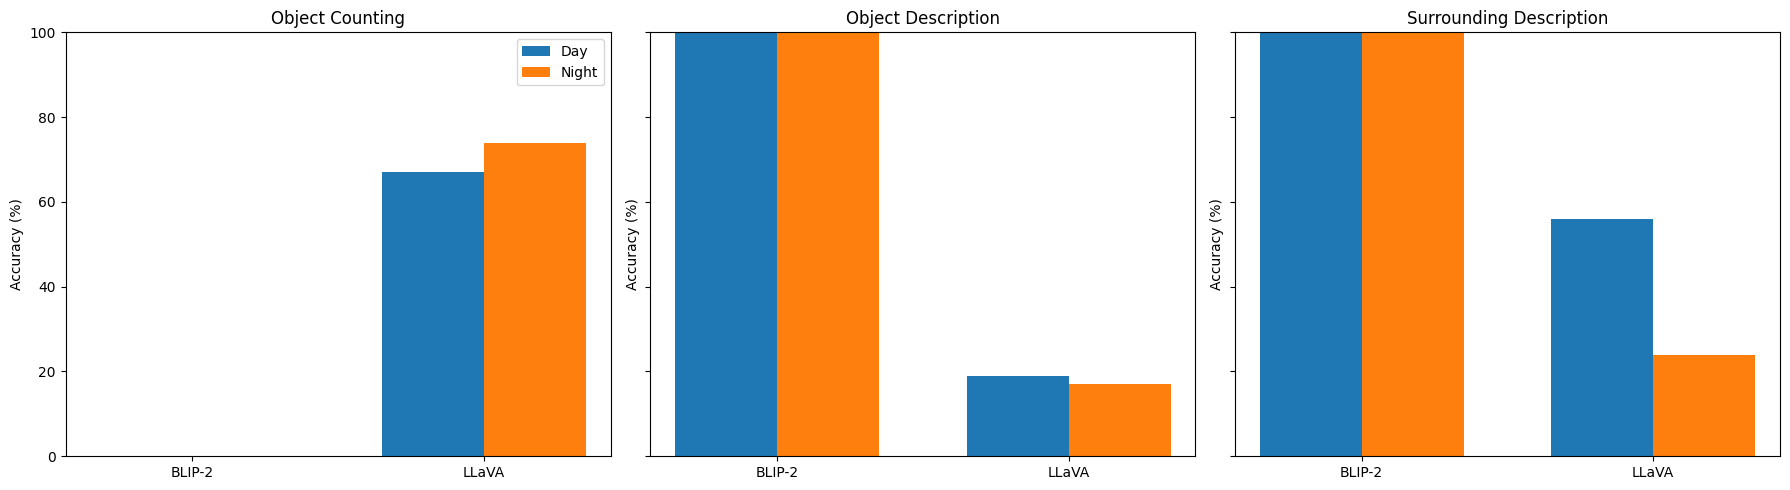

Saved: /kaggle/working/vlm_day_night_results/blip2_vs_llava_all_categories.png


In [26]:
import os
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

categories = compare_df["category"].unique()

for ax, category in zip(axes, categories):
    sub = compare_df[compare_df["category"] == category].copy()
    pivot = sub.pivot(index="model", columns="light", values="accuracy_percent").reset_index()

    x = np.arange(len(pivot))
    width = 0.35

    ax.bar(x - width/2, pivot["day"], width, label="Day")
    ax.bar(x + width/2, pivot["night"], width, label="Night")
    ax.set_xticks(x)
    ax.set_xticklabels(pivot["model"])
    ax.set_title(category)
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)

axes[0].legend()
plt.tight_layout()

combined_png = os.path.join(OUTPUT_DIR, "blip2_vs_llava_all_categories.png")
plt.savefig(combined_png, dpi=200)
plt.show()

print("Saved:", combined_png)

In [27]:
import os

OUTPUT_DIR = "/kaggle/working/vlm_day_night_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# save comparison table
compare_csv = os.path.join(OUTPUT_DIR, "blip2_vs_llava_comparison.csv")
compare_df.to_csv(compare_csv, index=False)

print("Comparison saved at:")
print(compare_csv)

print("\nFiles in folder:")
print(os.listdir(OUTPUT_DIR))

Comparison saved at:
/kaggle/working/vlm_day_night_results/blip2_vs_llava_comparison.csv

Files in folder:
['blip2_object_description_day_night.png', 'blip2_vs_llava_all_categories.png', 'llava_object_counting_day_night.png', 'llava_surrounding_description_day_night.png', 'llava_accuracy.csv', 'blip2_results.csv', 'blip2_vs_llava_surrounding_description.png', 'llava_object_description_day_night.png', 'blip2_vs_llava_comparison.csv', 'blip2_object_counting_day_night.png', 'blip2_surrounding_description_day_night.png', 'llava_results.csv', 'blip2_accuracy.csv', 'blip2_vs_llava_object_counting.png', 'blip2_vs_llava_object_description.png']


In [28]:
combined_png = os.path.join(OUTPUT_DIR, "blip2_vs_llava_all_categories.png")
plt.savefig(combined_png, dpi=200)
print("Chart saved at:")
print(combined_png)

Chart saved at:
/kaggle/working/vlm_day_night_results/blip2_vs_llava_all_categories.png


<Figure size 640x480 with 0 Axes>

In [29]:
print(os.path.exists(os.path.join(OUTPUT_DIR, "blip2_vs_llava_comparison.csv")))
print(os.path.exists(os.path.join(OUTPUT_DIR, "blip2_vs_llava_all_categories.png")))

True
True


In [30]:
import os
import zipfile

source_dir = "/kaggle/working/vlm_day_night_results"
zip_path = "/kaggle/working/vlm_day_night_results_backup.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(source_dir):
        for file in files:
            full_path = os.path.join(root, file)
            arcname = os.path.relpath(full_path, source_dir)
            zipf.write(full_path, arcname)

print("Backup zip created:", zip_path)
print("Exists:", os.path.exists(zip_path))

Backup zip created: /kaggle/working/vlm_day_night_results_backup.zip
Exists: True


In [31]:
import os
print(os.listdir("/kaggle/working/vlm_day_night_results"))

['blip2_object_description_day_night.png', 'blip2_vs_llava_all_categories.png', 'llava_object_counting_day_night.png', 'llava_surrounding_description_day_night.png', 'llava_accuracy.csv', 'blip2_results.csv', 'blip2_vs_llava_surrounding_description.png', 'llava_object_description_day_night.png', 'blip2_vs_llava_comparison.csv', 'blip2_object_counting_day_night.png', 'blip2_surrounding_description_day_night.png', 'llava_results.csv', 'blip2_accuracy.csv', 'blip2_vs_llava_object_counting.png', 'blip2_vs_llava_object_description.png']


In [32]:
import os
print(os.path.exists("/kaggle/working/vlm_day_night_results_backup.zip"))
print(os.listdir("/kaggle/working"))

True
['roadscapes_data', 'vqa_dataset_test_mapped.csv', '.virtual_documents', 'vlm_day_night_results_backup.zip', 'vlm_day_night_results']
